In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("500hits.csv", encoding = 'latin-1')

In [4]:
df.head()

,PLAYER,YRS,G,AB,R,H,2B,3B,HR,RBI,BB,SO,SB,CS,BA,HOF
0,Ty Cobb,24,3035,11434,2246,4189,724,295,117,726,1249,357,892,178,0.366,1
1,Stan Musial,22,3026,10972,1949,3630,725,177,475,1951,1599,696,78,31,0.331,1
2,Tris Speaker,22,2789,10195,1882,3514,792,222,117,724,1381,220,432,129,0.345,1
3,Derek Jeter,20,2747,11195,1923,3465,544,66,260,1311,1082,1840,358,97,0.310,1
4,Honus Wagner,21,2792,10430,1736,3430,640,252,101,0,963,327,722,15,0.329,1


In [91]:
df = df.drop(columns=['PLAYER', 'CS'])

In [92]:
X = df.iloc[:, 0:13]
y = df.iloc[:, 13]

In [93]:
from sklearn.model_selection import train_test_split

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=17 ,test_size= 0.2)

In [95]:
from sklearn.tree import DecisionTreeClassifier

In [96]:
dtc = DecisionTreeClassifier()

In [97]:
dtc.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [98]:
y_pred = dtc.predict(X_test)
print(y_pred)

[0 1 0 1 0 1 0 0 1 0 0 1 0 1 1 0 1 1 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 1 0
 0 1 0 1 0 1 0 0 0 1 1 0 0 0 0 0 0 1 0 0 1 1 0 1 0 1 0 0 0 1 1 1 1 1 0 0 0
 0 1 1 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 0]


In [99]:
dtc.score(X_test, y_test)

0.7741935483870968

In [100]:
from sklearn.metrics import confusion_matrix

In [101]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[49 12]
 [ 9 23]]


In [102]:
from sklearn.metrics import classification_report

In [103]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.80      0.82        61
           1       0.66      0.72      0.69        32

    accuracy                           0.77        93
   macro avg       0.75      0.76      0.76        93
weighted avg       0.78      0.77      0.78        93



In [104]:
dtc.feature_importances_

array([0.        , 0.02467692, 0.02053095, 0.07511482, 0.4098481 ,
       0.04297592, 0.01933433, 0.04585115, 0.04515849, 0.12554242,
       0.03117801, 0.04594388, 0.113845  ])

In [105]:
features = pd.DataFrame(dtc.feature_importances_, index = X.columns, columns = ["Importance"])

In [106]:
features.head(15)

,Importance
YRS,0.000000
G,0.024677
AB,0.020531
R,0.075115
H,0.409848
2B,0.042976
3B,0.019334
HR,0.045851
RBI,0.045158
BB,0.125542


In [107]:
features_sorted.head(15)

,Importance
YRS,0.000000
3B,0.025461
G,0.027434
SO,0.031178
SB,0.035733
RBI,0.045158
HR,0.048914
AB,0.055817
R,0.061636
2B,0.065804


## improvements

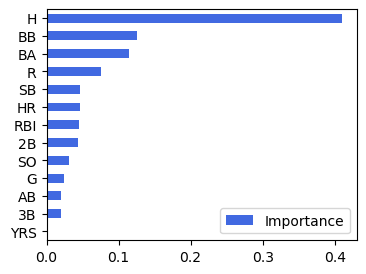

In [108]:
features_sorted = features.sort_values(by="Importance")

features_sorted.plot(kind = 'barh', color = 'royalblue', figsize=(4, 3))
plt.show()

In [109]:
from sklearn import tree

In [115]:
tree.export_graphviz(dtc, out_file = '500hits_dtc.dot',
                    feature_names=['YRS', 'G', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'BB', 'SO', 'SB','BA'],
                    label='all',
                    rounded=True,
                    filled=True
)